<a href="https://colab.research.google.com/github/ADII56-23/Machine_Leaning-lab/blob/main/Exp08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linkage Matrix (Step-by-Step Merges):
         Cluster 1  Cluster 2  Distance  Cluster Size
Merge 1        0.0        1.0  1.000000           2.0
Merge 2        2.0        3.0  1.414214           2.0
Merge 3        4.0        5.0  2.828427           4.0


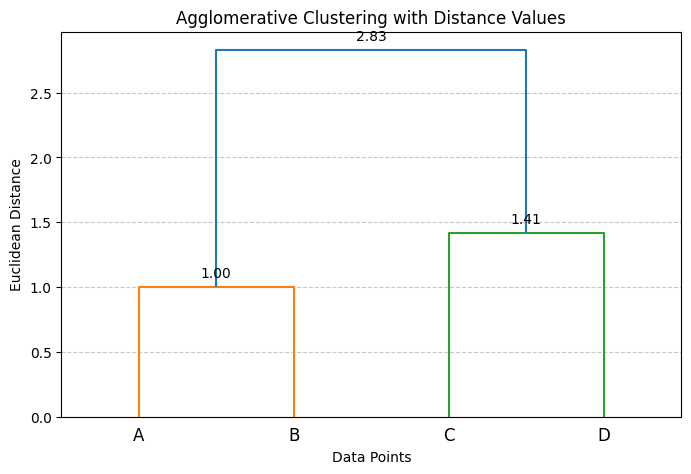

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Define the data points
points = np.array([
    [1, 1], # Index 0: A
    [2, 1], # Index 1: B
    [4, 3], # Index 2: C
    [5, 4]  # Index 3: D
])
labels = ['A', 'B', 'C', 'D']

# 2. Apply Agglomerative Clustering
Z = linkage(points, method='single', metric='euclidean')

# 3. Display the "Clean Values" (Linkage Matrix)
print("Linkage Matrix (Step-by-Step Merges):")
fmt_Z = pd.DataFrame(Z,
                     columns=['Cluster 1', 'Cluster 2', 'Distance', 'Cluster Size'],
                     index=[f'Merge {i+1}' for i in range(len(Z))])
print(fmt_Z)

plt.figure(figsize=(8, 5))
plt.title('Agglomerative Clustering with Distance Values')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')


dend = dendrogram(Z, labels=labels, leaf_rotation=0)

for i, d, eth in zip(Z[:, 0], Z[:, 1], Z[:, 2]):
    x = 0.5 * (dend['icoord'][np.where(Z[:, 2] == eth)[0][0]][1] +
               dend['icoord'][np.where(Z[:, 2] == eth)[0][0]][2])
    y = eth
    plt.annotate(f'{y:.2f}', (x, y), xytext=(0, 5),
                 textcoords='offset points', va='bottom', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()